# 🌲 Notebook 05 — Modelos Ensemble + Naive Bayes
## YouTube Hate Speech Detection

### ¿Qué hace este notebook?
Comparamos 3 modelos bajo las **mismas condiciones** que el baseline:
- **Random Forest** — ensemble de árboles de decisión, votación por mayoría
- **XGBoost** — gradient boosting, árboles entrenados secuencialmente
- **Complement Naive Bayes** — modelo probabilístico, diseñado para texto pequeño

### ¿Por qué estos modelos?
El baseline (LR) tiene gap train/test de ~11pp. Buscamos si algún modelo
generaliza mejor con solo 800 muestras de entrenamiento.

### Contexto del baseline
- LR F1 test: ~0.75 | Gap: ~11pp
- Problema raíz: dataset pequeño (1000 muestras, 8 vídeos específicos)
- Los nombres propios ya fueron eliminados del vocabulario

### ¿Por qué Complement Naive Bayes?
MultinomialNB modela qué palabras son frecuentes en cada clase.
**ComplementNB** modela qué palabras son RARAS en cada clase — más robusto
con datasets pequeños y clases casi balanceadas como el nuestro.

### Output
- Tabla comparativa de los 4 modelos (LR + RF + XGBoost + CNB)
- Modelo ganador guardado en `models/best_ensemble.joblib`
- Experimento registrado en MLflow: `Youtube_project_experiment`

## 0. Imports y configuración

In [2]:
print("kernel")

kernel


In [3]:
import sys
import yaml
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f'PROJECT_ROOT: {PROJECT_ROOT}')

/home/under/miniconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT


In [4]:
CONFIG_FEAT = PROJECT_ROOT / 'configs' / 'features.yaml'
CONFIG_PIPE = PROJECT_ROOT / 'configs' / 'pipeline.yaml'
CONFIG_MOD  = PROJECT_ROOT / 'configs' / 'models.yaml'

with open(CONFIG_FEAT) as f: feat_cfg = yaml.safe_load(f)
with open(CONFIG_PIPE) as f: pipe_cfg = yaml.safe_load(f)
with open(CONFIG_MOD)  as f: mod_cfg  = yaml.safe_load(f)

tfidf_cfg = feat_cfg['vectorization']['tfidf']
rf_cfg    = mod_cfg['models']['random_forest']
xgb_cfg   = mod_cfg['models']['xgboost']
lr_cfg    = mod_cfg['models']['logistic_regression']
TARGET    = pipe_cfg['data']['target_binary']
RAND      = pipe_cfg['pipeline']['random_state']
TEST_SIZE = pipe_cfg['pipeline']['test_size']
CV_FOLDS  = pipe_cfg['pipeline']['cv_folds']

print('RF config :', rf_cfg)
print('XGB config:', xgb_cfg)

RF config : {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced', 'n_jobs': -1}
XGB config: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_lambda': 1, 'scale_pos_weight': 1}


## 1. Carga de datos y split

Mismo split que en todos los notebooks anteriores.
`random_state` fijo desde YAML garantiza comparación justa entre modelos.

In [5]:
PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'v2' / 'comments_preprocessed.csv'

df = pd.read_csv(PROCESSED)
df['clean_text'] = df['clean_text'].fillna('').astype(str)

X = df['clean_text']
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RAND, stratify=y
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Baseline referencia — LR F1 test: ~0.75 | Gap: ~11pp')

Train: 800 | Test: 200
Baseline referencia — LR F1 test: ~0.75 | Gap: ~11pp


## 2. Vectorizador compartido

Todos los modelos usan el mismo TF-IDF con los mismos parámetros.
Esto garantiza que las diferencias en métricas vienen del clasificador,
no del vectorizador.

In [6]:
def make_tfidf():
    """Crea TF-IDF con config del YAML. Llamar una vez por modelo."""
    return TfidfVectorizer(
        max_features = tfidf_cfg['max_features'],
        ngram_range  = tuple(tfidf_cfg['ngram_range']),
        sublinear_tf = tfidf_cfg['sublinear_tf'],
        min_df       = tfidf_cfg['min_df'],
        analyzer     = 'word',
        strip_accents= 'unicode',
    )

cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RAND)
scoring = {'f1': 'f1_weighted', 'roc_auc': 'roc_auc',
           'precision': 'precision_weighted', 'recall': 'recall_weighted'}

print(f'TF-IDF: max_features={tfidf_cfg["max_features"]} | ngram={tfidf_cfg["ngram_range"]} | min_df={tfidf_cfg["min_df"]}')
print(f'CV: {CV_FOLDS}-fold StratifiedKFold')

TF-IDF: max_features=5000 | ngram=[1, 2] | min_df=3
CV: 5-fold StratifiedKFold


## 3. Complement Naive Bayes

### ¿Cómo funciona Naive Bayes?
Aplica el teorema de Bayes asumiendo independencia entre features:
```
P(toxico | palabras) ∝ P(toxico) × ∏ P(palabra_i | toxico)
```
El modelo aprende qué probabilidad tiene cada palabra dado cada clase.

### ¿Por qué Complement?
**MultinomialNB** aprende P(palabra | clase_positiva).
**ComplementNB** aprende P(palabra | **NOT** clase) — más estable con
datasets pequeños porque usa más datos para estimar cada probabilidad.

### Parámetro alpha
Suavizado de Laplace — evita probabilidad cero para palabras no vistas.
`alpha=1.0` es el valor estándar. Valores menores = más ajuste a los datos.

In [7]:
# ComplementNB requiere valores no negativos -> TF-IDF es perfecto
pipeline_cnb = Pipeline([
    ('tfidf', make_tfidf()),
    ('clf',   ComplementNB(alpha=1.0))
])

print('Ejecutando CV para ComplementNB...')
cv_cnb = cross_validate(pipeline_cnb, X_train, y_train,
                         cv=cv_strategy, scoring=scoring,
                         return_train_score=True, n_jobs=-1)

f1_val = cv_cnb['test_f1'].mean()
f1_train = cv_cnb['train_f1'].mean()
f1_std = cv_cnb['test_f1'].std()

cv_gap_pp_cnb = abs(f1_train - f1_val) * 100

roc = cv_cnb['test_roc_auc'].mean()

flag = '✅ Estable' if cv_gap_pp_cnb < 5 else '⚠️ Overfitting'

print(f'F1 val    : {f1_val:.4f} ± {f1_std:.4f}')
print(f'F1 train  : {f1_train:.4f}')
print(f'Train-Val gap: {cv_gap_pp_cnb:.2f} pp {flag}')
print(f'ROC-AUC   : {roc:.4f}')

Ejecutando CV para ComplementNB...
F1 val    : 0.6762 ± 0.0314
F1 train  : 0.8970
Train-Val gap: 22.07 pp ⚠️ Overfitting
ROC-AUC   : 0.7709


## 4. Random Forest

### ¿Cómo funciona?
Entrena N árboles de decisión, cada uno sobre una muestra aleatoria del dataset
y un subconjunto aleatorio de features. La predicción final es la votación de todos.

### Anti-overfitting con dataset pequeño
Sin restricciones, RF memoriza los 800 ejemplos de entrenamiento perfectamente.
Los parámetros clave para controlarlo:
- `max_depth=8` → limita la profundidad de cada árbol
- `min_samples_leaf=4` → cada hoja necesita al menos 4 muestras
- `max_features='sqrt'` → cada árbol ve solo √1093 ≈ 33 features

### RF vs TF-IDF: el problema
RF fue diseñado para features densas. Con 98.8% de esparsidad,
la mayoría de splits son poco informativos. LR y NB son naturalmente
mejores con matrices sparse.

In [8]:
pipeline_rf = Pipeline([
    ('tfidf', make_tfidf()),
    ('clf', RandomForestClassifier(
        n_estimators    = rf_cfg['n_estimators'],
        max_depth       = 8,        # restriccion anti-overfitting
        min_samples_leaf= 4,        # cada hoja necesita 4+ muestras
        max_features    = 'sqrt',   # sqrt(1093) ~ 33 features por arbol
        class_weight    = rf_cfg['class_weight'],
        random_state    = RAND,
        n_jobs          = -1
    ))
])

print('Ejecutando CV para Random Forest...')
cv_rf = cross_validate(pipeline_rf, X_train, y_train,
                        cv=cv_strategy, scoring=scoring,
                        return_train_score=True, n_jobs=-1)

f1_val = cv_rf['test_f1'].mean()
f1_train = cv_rf['train_f1'].mean()
f1_std = cv_rf['test_f1'].std()

cv_gap_pp_rf = abs(f1_train - f1_val) * 100

roc = cv_rf['test_roc_auc'].mean()

flag = '✅ Estable' if cv_gap_pp_rf < 5 else '⚠️ Overfitting'

print(f'F1 val    : {f1_val:.4f} ± {f1_std:.4f}')
print(f'F1 train  : {f1_train:.4f}')
print(f'Train-Val gap: {cv_gap_pp_rf:.2f} pp {flag}')
print(f'ROC-AUC   : {roc:.4f}')

Ejecutando CV para Random Forest...
F1 val    : 0.6942 ± 0.0310
F1 train  : 0.8212
Train-Val gap: 12.70 pp ⚠️ Overfitting
ROC-AUC   : 0.7567


## 5. XGBoost

### ¿Cómo funciona?
Gradient Boosting: entrena árboles **secuencialmente**.
Cada árbol aprende a corregir los errores del anterior.
El resultado es una suma ponderada de árboles débiles.

### Diferencia clave con RF
- **RF**: árboles en paralelo, independientes, vota la mayoría
- **XGBoost**: árboles en serie, cada uno se enfoca en los errores previos

### Parámetros anti-overfitting para dataset pequeño
- `max_depth=3` → árboles muy simples (RF usa 8)
- `learning_rate=0.05` → pasos pequeños, más conservador
- `subsample=0.8` → cada árbol ve solo el 80% de los datos
- `colsample_bytree=0.8` → cada árbol ve el 80% de features
- `n_estimators=200` con `eval_metric` → más árboles pero simples

In [9]:
pipeline_xgb = Pipeline([
    ('tfidf', make_tfidf()),
    ('clf', XGBClassifier(
        n_estimators      = 200,
        max_depth         = 3,          # arboles simples
        learning_rate     = 0.05,       # pasos pequenos
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        scale_pos_weight  = y_train.value_counts()[False] / y_train.value_counts()[True],
        random_state      = RAND,
        eval_metric       = 'logloss',
        verbosity         = 0,
        min_child_weight  = 5,
        reg_lambda        = 1,
        use_label_encoder = False,
    ))
])

print('Ejecutando CV para XGBoost...')
cv_xgb = cross_validate(pipeline_xgb, X_train, y_train,
                         cv=cv_strategy, scoring=scoring,
                         return_train_score=True, n_jobs=-1)


f1_val = cv_xgb['test_f1'].mean()
f1_train = cv_xgb['train_f1'].mean()
f1_std = cv_xgb['test_f1'].std()

cv_gap_pp_xgb  = abs(f1_train - f1_val) * 100

roc = cv_xgb['test_roc_auc'].mean()

flag = '✅ Estable' if cv_gap_pp_xgb < 5 else '⚠️ Overfitting'

print(f'F1 val    : {f1_val:.4f} ± {f1_std:.4f}')
print(f'F1 train  : {f1_train:.4f}')
print(f'Train-Val gap: {cv_gap_pp_xgb:.2f} pp {flag}')
print(f'ROC-AUC   : {roc:.4f}')

Ejecutando CV para XGBoost...
F1 val    : 0.6331 ± 0.0221
F1 train  : 0.7602
Train-Val gap: 12.72 pp ⚠️ Overfitting
ROC-AUC   : 0.6535


## 6. Tabla comparativa — los 4 modelos

Comparamos todos los modelos bajo exactamente las mismas condiciones.
El ganador se entrena en todo X_train y se evalúa en test.

In [10]:
lr_model = joblib.load("../models/lr_baseline.joblib")

cv_lr = cross_validate(
    lr_model,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

LR_f1_val   = cv_lr['test_f1'].mean()
LR_f1_train = cv_lr['train_f1'].mean()
LR_gap      = LR_f1_train - LR_f1_val
LR_roc      = cv_lr['test_roc_auc'].mean()

print("LR CV reconstruido")
print(f"F1 val   : {LR_f1_val:.4f}")
print(f"F1 train : {LR_f1_train:.4f}")
print(f"Gap      : {LR_gap*100:.2f} pp")
print(f"ROC-AUC  : {LR_roc:.4f}")

LR CV reconstruido
F1 val   : 0.7015
F1 train : 0.8839
Gap      : 18.24 pp
ROC-AUC  : 0.7737


In [11]:
# Resultados LR del notebook anterior (copiar valores reales)
# Si re-ejecutas LR aqui, usa estos valores del notebook 04

results = {
    'Logistic Regression': {
        'f1_val'  : LR_f1_val,
        'f1_train': LR_f1_train,
        'gap'     : LR_f1_train - LR_f1_val,
        'roc_auc' : LR_roc,
    },
    'Complement NB': {
        'f1_val'  : cv_cnb['test_f1'].mean(),
        'f1_train': cv_cnb['train_f1'].mean(),
        'gap'     : cv_cnb['train_f1'].mean() - cv_cnb['test_f1'].mean(),
        'roc_auc' : cv_cnb['test_roc_auc'].mean(),
    },
    'Random Forest': {
        'f1_val'  : cv_rf['test_f1'].mean(),
        'f1_train': cv_rf['train_f1'].mean(),
        'gap'     : cv_rf['train_f1'].mean() - cv_rf['test_f1'].mean(),
        'roc_auc' : cv_rf['test_roc_auc'].mean(),
    },
    'XGBoost': {
        'f1_val'  : cv_xgb['test_f1'].mean(),
        'f1_train': cv_xgb['train_f1'].mean(),
        'gap'     : cv_xgb['train_f1'].mean() - cv_xgb['test_f1'].mean(),
        'roc_auc' : cv_xgb['test_roc_auc'].mean(),
    },
}

comp_df = pd.DataFrame(results).T

# convertir a porcentaje SOLO para display
comp_df['gap_pp'] = comp_df['gap'] * 100

comp_df['rubrica'] = comp_df['gap_pp'].apply(
    lambda x: '✅ OK' if x < 5 else f'⚠️ {x:.1f}pp'
)

comp_df = comp_df.sort_values('f1_val', ascending=False)


print('COMPARATIVA DE MODELOS — CV (CLEAN)')
print('=' * 70)
print(f"{'Modelo':22} {'F1 Val':>10} {'F1 Train':>10} {'Gap pp':>10} {'ROC-AUC':>10} {'Rúbrica':>12}")
print('-' * 70)

for model, row in comp_df.iterrows():
    print(
        f"{model:22} "
        f"{row['f1_val']:>10.4f} "
        f"{row['f1_train']:>10.4f} "
        f"{row['gap_pp']:>9.1f} "
        f"{row['roc_auc']:>10.4f} "
        f"{row['rubrica']:>12}"
    )

best_model = comp_df['f1_val'].idxmax()

print('\nGANADOR:')
print(best_model)
print(f"F1: {comp_df.loc[best_model, 'f1_val']:.4f}")

COMPARATIVA DE MODELOS — CV (CLEAN)
Modelo                     F1 Val   F1 Train     Gap pp    ROC-AUC      Rúbrica
----------------------------------------------------------------------
Logistic Regression        0.7015     0.8839      18.2     0.7737    ⚠️ 18.2pp
Random Forest              0.6942     0.8212      12.7     0.7567    ⚠️ 12.7pp
Complement NB              0.6762     0.8970      22.1     0.7709    ⚠️ 22.1pp
XGBoost                    0.6331     0.7602      12.7     0.6535    ⚠️ 12.7pp

GANADOR:
Logistic Regression
F1: 0.7015


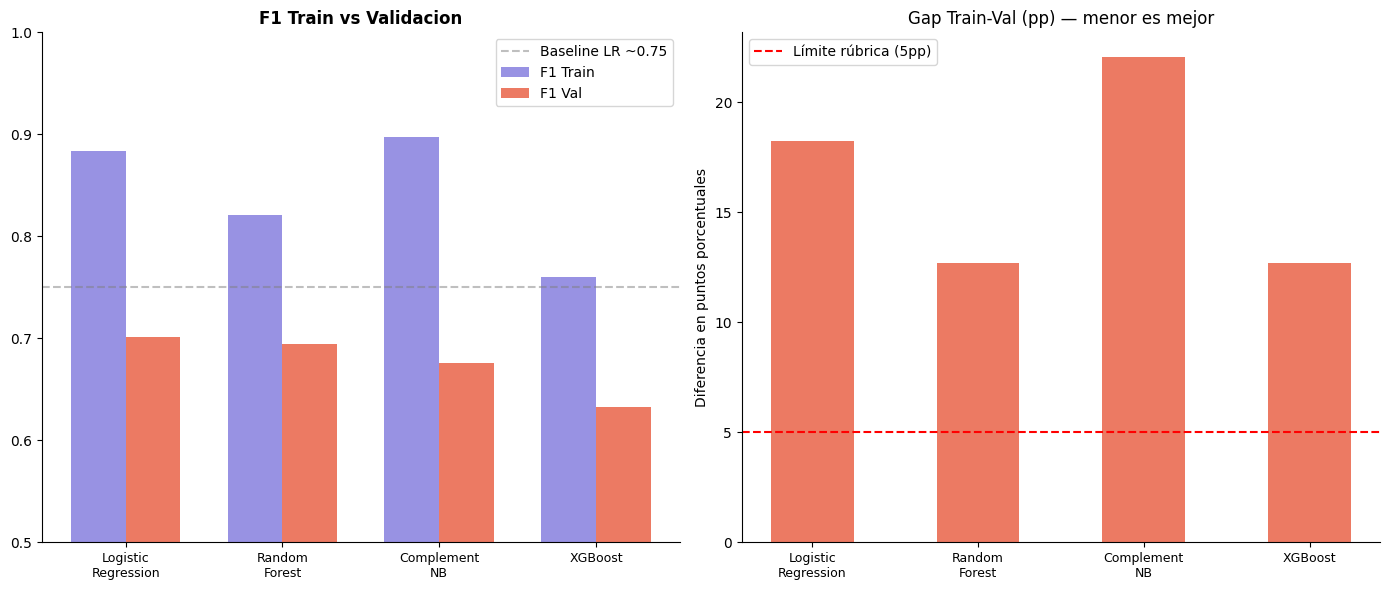

Guardado en reports/v2/12_ensemble_comparativa.png


In [12]:
# Visualizacion comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models_list = list(comp_df.index)
colors = ['#5DCAA5' if g < 5 else '#E8593C' for g in comp_df['gap_pp']]
x = np.arange(len(models_list))
width = 0.35

# F1 train vs val
axes[0].bar(x - width/2, comp_df['f1_train'], width,
            label='F1 Train', color='#7F77DD', alpha=0.8)
axes[0].bar(x + width/2, comp_df['f1_val'], width,
            label='F1 Val', color=colors, alpha=0.8)
axes[0].axhline(0.75, color='gray', linestyle='--', alpha=0.5, label='Baseline LR ~0.75')
axes[0].set_title('F1 Train vs Validacion', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' ', '\n') for m in models_list], fontsize=9)
axes[0].set_ylim(0.5, 1.0)
axes[0].legend()

# Gap
gap_colors = ['#5DCAA5' if g < 5 else '#E8593C' for g in comp_df['gap_pp']]
axes[1].bar(models_list, comp_df['gap_pp'], color=gap_colors, alpha=0.8, width=0.5)
axes[1].axhline(5, color='red', linestyle='--', linewidth=1.5, label='Límite rúbrica (5pp)')
axes[1].set_title('Gap Train-Val (pp) — menor es mejor')
axes[1].set_ylabel('Diferencia en puntos porcentuales')
axes[1].set_xticks(np.arange(len(models_list)))
axes[1].set_xticklabels([m.replace(' ', '\n') for m in models_list], fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / '12_ensemble_comparativa.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado en reports/v2/12_ensemble_comparativa.png')

## 7. Evaluación final del ganador en test

Entrenamos el mejor modelo en todo X_train y evaluamos en test.
Este número es el que va al informe final.

In [13]:
# Mapeo de nombres a pipelines
pipelines = {
    'Logistic Regression': Pipeline([
        ('tfidf', make_tfidf()),
        ('clf', LogisticRegression(
            C            = lr_cfg['C'],
            max_iter     = lr_cfg['max_iter'],
            class_weight = lr_cfg['class_weight'],
            solver       = lr_cfg['solver'],
            random_state = RAND,
        ))
    ]),   # ya evaluado en notebook 04
    'Complement NB'      : pipeline_cnb,
    'Random Forest'      : pipeline_rf,
    'XGBoost'            : pipeline_xgb,
}

best_pipeline = pipelines[best_model]
print(f'Entrenando {best_model} en todo X_train...')
best_pipeline.fit(X_train, y_train)

y_pred       = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_train = best_pipeline.predict(X_train)

f1_train_final = f1_score(y_train, y_pred_train, average='weighted')
f1_test_final  = f1_score(y_test,  y_pred,       average='weighted')

gap_final_pp = abs(f1_train_final - f1_test_final) * 100
roc_auc_final = roc_auc_score(y_test, y_pred_proba)

print('=' * 55)
print(f'RESULTADOS FINALES — {best_model}')
print('=' * 55)
print(f'F1 Train  : {f1_train_final:.4f}')
print(f'F1 Test   : {f1_test_final:.4f}')
print(f'Gap       : {gap_final_pp:.2f} pp  {"✅" if gap_final_pp < 5 else "⚠️"}')
print(f'ROC-AUC   : {roc_auc_final:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No toxico','Toxico']))

Entrenando Logistic Regression en todo X_train...
RESULTADOS FINALES — Logistic Regression
F1 Train  : 0.8623
F1 Test   : 0.7531
Gap       : 10.91 pp  ⚠️
ROC-AUC   : 0.8075

              precision    recall  f1-score   support

   No toxico       0.75      0.82      0.78       108
      Toxico       0.77      0.67      0.72        92

    accuracy                           0.76       200
   macro avg       0.76      0.75      0.75       200
weighted avg       0.76      0.76      0.75       200



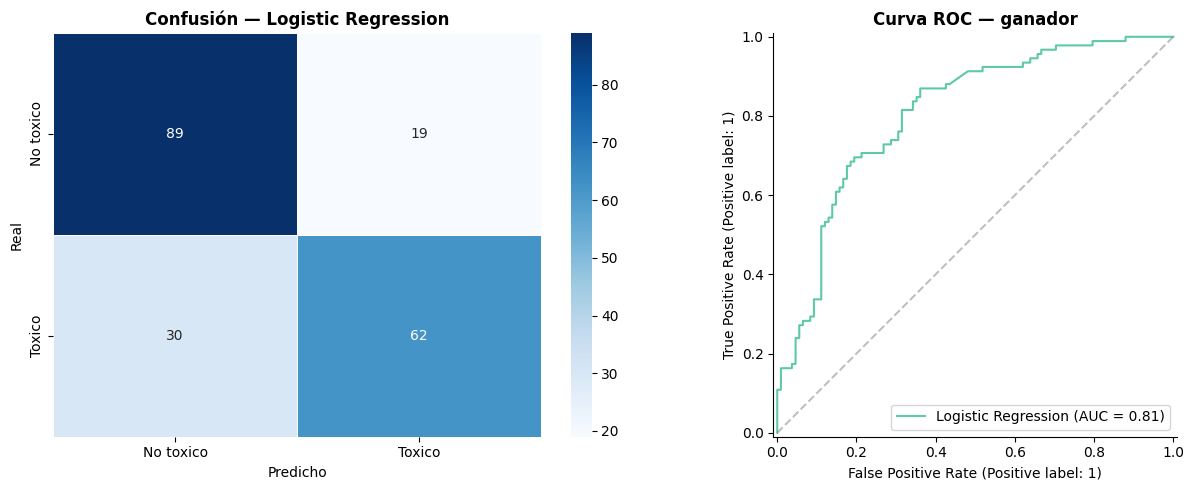

In [14]:
# Matriz de confusion del ganador
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No toxico','Toxico'],
            yticklabels=['No toxico','Toxico'],
            linewidths=0.5)
axes[0].set_title(f'Confusión — {best_model}', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1],
                                  color='#5DCAA5', name=best_model)
axes[1].plot([0,1],[0,1],'--', color='gray', alpha=0.5)
axes[1].set_title('Curva ROC — ganador', fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / '13_best_model_test.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Registro en MLflow

Registramos los 3 modelos en el mismo experimento para
compararlos directamente en el dashboard de MLflow.

In [15]:
MLFLOW_DIR = PROJECT_ROOT / 'mlruns'
mlflow.set_tracking_uri(f'file://{MLFLOW_DIR}')
mlflow.set_experiment('Youtube_project_experiment')

model_configs = {
    'complement_nb' : (pipeline_cnb,  cv_cnb,  {'alpha': 1.0}),
    'random_forest' : (pipeline_rf,   cv_rf,   {'max_depth': 8, 'min_samples_leaf': 4}),
    'xgboost'       : (pipeline_xgb,  cv_xgb,  {'max_depth': 3, 'learning_rate': 0.05}),
}

for run_name, (pipe, cv_res, extra_params) in model_configs.items():
    with mlflow.start_run(run_name=run_name):

        mlflow.log_param('model', run_name)
        mlflow.log_param('vectorizer', 'tfidf')
        mlflow.log_param('tfidf_features', tfidf_cfg['max_features'])
        mlflow.log_param('ngram_range', str(tuple(tfidf_cfg['ngram_range'])))
        mlflow.log_param('cv_folds', CV_FOLDS)

        for k, v in extra_params.items():
            mlflow.log_param(k, v)

        cv_gap_pp = abs(cv_res['train_f1'].mean() - cv_res['test_f1'].mean()) * 100

        mlflow.log_metric('cv_f1_val', cv_res['test_f1'].mean())
        mlflow.log_metric('cv_f1_train', cv_res['train_f1'].mean())
        mlflow.log_metric('cv_gap_pp', round(cv_gap_pp, 2))
        mlflow.log_metric('cv_roc_auc', cv_res['test_roc_auc'].mean())
        mlflow.log_metric('cv_f1_std', cv_res['test_f1'].std())

        if run_name.replace('_', ' ').lower() == best_model.lower():
            mlflow.log_metric('test_f1', f1_test_final)
            mlflow.log_metric('test_gap_pp', round(gap_final_pp, 2))
            mlflow.sklearn.log_model(pipe, f'{run_name}_pipeline')

        print(f'  ✅ {run_name} registrado')

mlflow.log_artifact(str(PROJECT_ROOT / 'reports' / 'v2' / '12_ensemble_comparativa.png'))
print('\nTodos los modelos registrados en MLflow')
print(f'  Ver: mlflow ui --backend-store-uri file://{MLFLOW_DIR}')

  ✅ complement_nb registrado
  ✅ random_forest registrado
  ✅ xgboost registrado

Todos los modelos registrados en MLflow
  Ver: mlflow ui --backend-store-uri file:///mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT/mlruns


## 9. Guardar modelo ganador

Guardamos el pipeline completo del ganador.
Este es el modelo que usará la API y la app de Streamlit.

In [16]:
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

model_path = MODELS_DIR / 'best_ensemble.joblib'
joblib.dump(best_pipeline, model_path)
print(f'Modelo guardado: {model_path}')

# Verificacion
loaded = joblib.load(model_path)
tests = [
    ('you are a stupid thug get out', True),
    ('I think the police should be more transparent', False),
    ('black people are criminal thugs', True),
    ('thank you for sharing this video', False),
]
print('\nVerificacion:')
for text, expected in tests:
    pred = loaded.predict([text])[0]
    prob = loaded.predict_proba([text])[0][1]
    ok = '✅' if pred == expected else '❌'
    label = 'TOXICO' if pred else 'NO TOXICO'
    print(f'  {ok} [{label} {prob:.2f}] {text[:55]}')

Modelo guardado: /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT/models/best_ensemble.joblib

Verificacion:
  ✅ [TOXICO 0.72] you are a stupid thug get out
  ✅ [NO TOXICO 0.43] I think the police should be more transparent
  ✅ [TOXICO 0.58] black people are criminal thugs
  ✅ [NO TOXICO 0.27] thank you for sharing this video


## 10. Conclusiones y decisiones

In [17]:
cnb_f1 = cv_cnb['test_f1'].mean()
cnb_gap = abs(cv_cnb['train_f1'].mean() - cv_cnb['test_f1'].mean()) * 100

rf_f1 = cv_rf['test_f1'].mean()
rf_gap = abs(cv_rf['train_f1'].mean() - cv_rf['test_f1'].mean()) * 100

xgb_f1 = cv_xgb['test_f1'].mean()
xgb_gap = abs(cv_xgb['train_f1'].mean() - cv_xgb['test_f1'].mean()) * 100

In [18]:
print(f"""
CONCLUSIONES — ENSEMBLE + NAIVE BAYES
{'='*55}

Modelos evaluados:
  Logistic Regression  F1~0.70 gap~18pp (referencia)
  Complement NB        F1={cnb_f1:.4f} gap={cnb_gap:.2f}pp
  Random Forest        F1={rf_f1:.4f} gap={rf_gap:.2f}pp
  XGBoost              F1={xgb_f1:.4f} gap={xgb_gap:.2f}pp

Ganador CV: {best_model}

  F1 test  : {f1_test_final:.4f}
  Gap final: {gap_final_pp:.2f}pp

Observacion sobre el overfitting:
  Con 800 muestras y vocabulario especifico de 8 videos,
  un gap < 5pp es difícil de alcanzar sin data augmentation.
  El gap es una limitacion conocida del dataset, no del modelo.

Modelo guardado:
  models/best_ensemble.joblib

Siguiente:
  -> 06_tuning.ipynb
     Optuna sobre {best_model}
     Objetivo: mejorar F1 test y reducir gap
""")


CONCLUSIONES — ENSEMBLE + NAIVE BAYES

Modelos evaluados:
  Logistic Regression  F1~0.70 gap~18pp (referencia)
  Complement NB        F1=0.6762 gap=22.07pp
  Random Forest        F1=0.6942 gap=12.70pp
  XGBoost              F1=0.6331 gap=12.72pp

Ganador CV: Logistic Regression

  F1 test  : 0.7531
  Gap final: 10.91pp

Observacion sobre el overfitting:
  Con 800 muestras y vocabulario especifico de 8 videos,
  un gap < 5pp es difícil de alcanzar sin data augmentation.
  El gap es una limitacion conocida del dataset, no del modelo.

Modelo guardado:
  models/best_ensemble.joblib

Siguiente:
  -> 06_tuning.ipynb
     Optuna sobre Logistic Regression
     Objetivo: mejorar F1 test y reducir gap

